# 02 Collect Sources

USGS active streamgages, reviewed streamgage network artifacts, STREAM-geo/NLDI river geometry, STREAM-geo/NLDI river geometry, direct AORC SST rainfall members, and NWM soil-moisture context.


In [ ]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display
import geopandas as gpd
import matplotlib.pyplot as plt
from design_events.collect_sources.nwm import soil_moisture_csv_has_variables
from design_events.collect_sources.usgs_streamgages import (
    active_streamgage_candidate_artifact_ready,
    collect_usgs_streamflow_records,
    discover_active_streamgage_candidates,
)

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

import design_events.collect_sources.workflow as collect

runtime = collect.load_runtime(location_root)
runtime_config = runtime.runtime_config
runtime_paths = runtime.runtime_paths
config = runtime.runtime_config
paths = runtime.runtime_paths
reviewed_network_path = runtime.reviewed_network_path

display(collect.summary(config, paths))
display(collect.source_records(runtime))

location                                                   greensboro
sources_root        /home/grahamhults/projects/Flood-RM/locations/...
collection_start                                           1979-02-01
collection_end                                             2022-12-31
Name: source_collection, dtype: str

,record,configured,location_root_syntax,exists
0,active USGS streamgage candidates,data/sources/usgs_streamgages/streamgage_candi...,"location_root / ""data/sources/usgs_streamgages...",True
1,reviewed streamgage network,data/sources/usgs_streamgages/streamgage_netwo...,"location_root / ""data/sources/usgs_streamgages...",True
2,reviewed discharge records,data/sources/usgs_streamgages/streamflow_recor...,"location_root / ""data/sources/usgs_streamgages...",True
3,AORC rainfall members,data/sources/aorc_sst/rainfall_members.csv,"location_root / ""data/sources/aorc_sst/rainfal...",True
4,NWM soil-moisture members,data/sources/nwm/soil_moisture.csv,"location_root / ""data/sources/nwm/soil_moistur...",True
5,STREAM-geo river geometry cache,data/sources/national_hydrography/stream_geo.p...,"location_root / ""data/sources/national_hydrogr...",True
6,NLDI STREAM-geo COMID join cache,data/sources/national_hydrography/nldi_stream_...,"location_root / ""data/sources/national_hydrogr...",False
7,NHDPlusV2 flowlines for STREAM-geo join,data/sources/national_hydrography/nhdplus_v2_f...,"location_root / ""data/sources/national_hydrogr...",False
8,NHDPlus river geometry,data/sources/national_hydrography/nhdplus_hr_r...,"location_root / ""data/sources/national_hydrogr...",True
9,NHDPlus catchments,data/sources/national_hydrography/nhdplus_hr_c...,"location_root / ""data/sources/national_hydrogr...",True


## Rerun Control

In [ ]:
rerun = False

## Source Collection Plan

In [ ]:
plan = collect.plan(config, paths)
plan_table = collect.plan_table(
    plan,
    paths,
    rerun=rerun,
)
display(plan_table)

,source,start,end,will_reuse_existing,action
0,usgs_streamgages,1979-02-01,2022-12-31,True,reuse complete artifact
1,stream_geo_nldi,1979-02-01,2022-12-31,True,reuse complete artifact
2,national_hydrography,1979-02-01,2022-12-31,True,reuse complete artifact
3,nwm,1979-02-01,2022-12-31,True,reuse complete artifact
4,aorc_sst,1979-02-01,2022-12-31,True,reuse complete artifact


## USGS Active Streamgage Discovery

In [4]:
discovery_summary, records_summary = collect.discover_gages(runtime)
display(discovery_summary)
display(records_summary)
display(collect.gage_readiness(runtime))


provider                                                           USGS NWIS
site_service_url                   https://waterservices.usgs.gov/nwis/site/
parameter_cd                                                           00060
site_status                                                           active
data_types                                                                dv
bbox                                -80.628878,35.135683,-77.99173,37.218212
search_geometry             data/static/aoi/wflow_nhdplus_watersheds.geojson
hydrologic_buffer_km                                                      50
active_records_only                                                     True
candidate_output           data/sources/usgs_streamgages/streamgage_candi...
candidate_output_exists                                                 True
Name: usgs_active_streamgage_discovery, dtype: object

records_service                                                           dv
records_output             data/sources/usgs_streamgages/streamflow_recor...
records_output_exists                                                   True
request_timeout_seconds                                                   60
stat_cd                                                                00003
Name: usgs_reviewed_discharge_records, dtype: object

,artifact,path,exists,ready
0,streamgage candidates,/home/grahamhults/projects/Flood-RM/locations/...,True,True
9,soil moisture,/home/grahamhults/projects/Flood-RM/locations/...,True,True


## Streamgage Review Gate

In [5]:
display(collect.review_summary(runtime))
display(collect.review_sources(runtime))


review_required                                                                     True
accept_unreviewed_streamgage_network                                               False
method                                                                        huc_region
source_geometry                         data/static/aoi/wflow_nhdplus_watersheds.geojson
geometry_predicate                                                                covers
review_status                                                      accepted_with_warning
roles                                                 frequency, calibration, validation
frequency_basis_from                                                   wflow_submodel_id
wflow_submodel_id_from                                                 wflow_submodel_id
sfincs_domain_id_from                                                   sfincs_domain_id
Name: streamgage_review, dtype: object

,method,source_geometry,frequency_basis_from,wflow_submodel_id_from,sfincs_domain_id_from
0,huc_region,data/static/aoi/wflow_nhdplus_watersheds.geojson,wflow_submodel_id,wflow_submodel_id,sfincs_domain_id


## Stochastic Storm Transposition Region

The SST region is the configured AORC SST transposition polygon.


transposition_region           data/sources/aorc_sst/transposition_regions/tr...
transposition_region_exists                                                 True
grid_footprint                                data/static/aoi/study_area.geojson
grid_footprint_exists                                                       True
plot_crs                                                               EPSG:3857
analysis_crs                                                           EPSG:4326
Name: aorc_sst_region_inputs, dtype: object

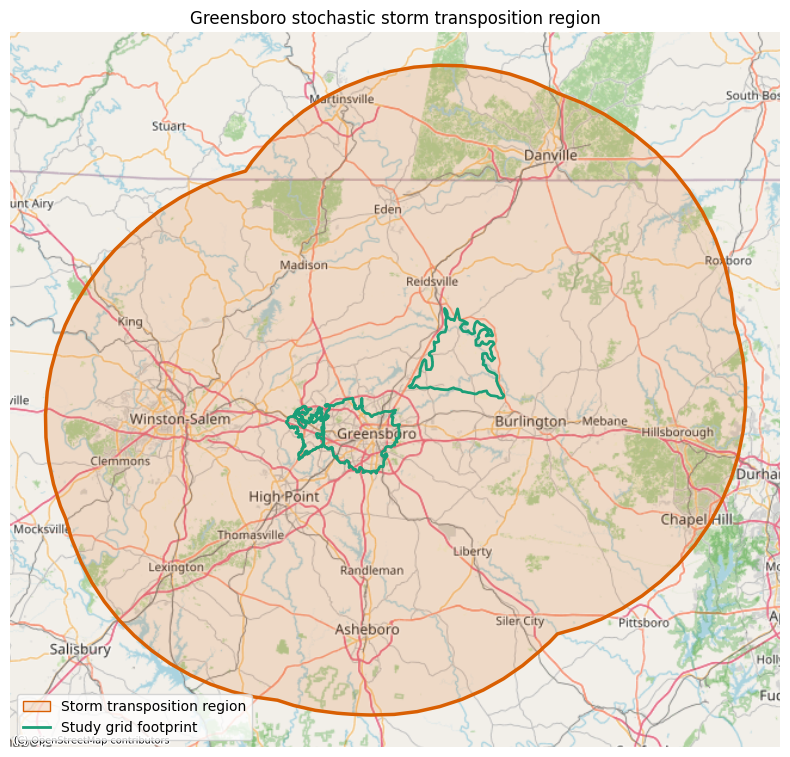

In [6]:
# Plot the configured AORC SST transposition region before pulling rainfall members.
def _location_path(value):
    path = Path(value)
    if path.is_absolute():
        return path
    if path.parts and path.parts[0] in {"data", "02_flood", "01_grid"}:
        return paths["location_root"] / path
    return paths["repo_root"] / path


def plot_sst_region(config, paths, zoom=9, basemap=True):
    import geopandas as gpd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    import contextily as ctx

    region_file = config["collection"]["aorc_sst"]["transposition_region"]["geometry_file"]
    footprint_file = config["grid_footprint"]["source"]
    region_path = _location_path(region_file)
    footprint_path = _location_path(footprint_file)

    display(pd.Series({
        "transposition_region": region_file,
        "transposition_region_exists": region_path.exists(),
        "grid_footprint": footprint_file,
        "grid_footprint_exists": footprint_path.exists(),
        "plot_crs": "EPSG:3857",
        "analysis_crs": "EPSG:4326",
    }, name="aorc_sst_region_inputs"))

    region = gpd.read_file(region_path).to_crs("EPSG:4326")
    footprint = gpd.read_file(footprint_path).to_crs("EPSG:4326")
    region_web = region.to_crs(epsg=3857)
    footprint_web = footprint.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(8, 8))
    region_web.plot(ax=ax, facecolor="#d95f0226", edgecolor="#d95f02", linewidth=2.5)
    footprint_web.boundary.plot(ax=ax, color="#1b9e77", linewidth=2.0)

    xmin, ymin, xmax, ymax = region_web.total_bounds
    pad_x = (xmax - xmin) * 0.05
    pad_y = (ymax - ymin) * 0.05
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    if basemap:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=zoom, attribution_size=7)

    ax.legend(
        handles=[
            Patch(facecolor="#d95f0226", edgecolor="#d95f02", label="Storm transposition region"),
            Line2D([0], [0], color="#1b9e77", linewidth=2.0, label="Study grid footprint"),
        ],
        loc="lower left",
    )
    ax.set_axis_off()
    ax.set_title(f"{paths['location_name'].title()} stochastic storm transposition region")
    fig.tight_layout()
    return fig, ax


fig, ax = plot_sst_region(config, paths)


## STREAM-geo/NLDI River Geometry

STREAM-geo width/depth estimates are cached for native Wflow river-geometry enrichment; NLDI is retained as the COMID lookup provenance path.


In [7]:
display(collect.stream_sources(config, paths))


source                                                           STREAM-geo/NLDI
stream_geo_table               data/sources/national_hydrography/stream_geo.p...
stream_geo_table_exists                                                     True
nldi_lookup_cache              data/sources/national_hydrography/nldi_stream_...
nldi_lookup_cache_exists                                                   False
nhdplus_v2_flowlines           data/sources/national_hydrography/nhdplus_v2_f...
nhdplus_v2_flowlines_exists                                                False
stream_geo_join_method                                        attribute_transfer
nldi_role                                                COMID lookup provenance
manifest                       /home/grahamhults/projects/Flood-RM/locations/...
manifest_exists                                                             True
Name: stream_geo_nldi, dtype: object

## Direct AORC SST Rainfall Members

The direct AORC SST collector scans the transposition region, ranks rolling storm windows, and writes the rainfall-member table used to pair precipitation with streamflow and antecedent soil-moisture states.


In [8]:
aorc_sst = config["collection"].get("aorc_sst", {})

display(pd.Series({
    "source": "direct_aorc_sst",
    "transposition_region_id": aorc_sst.get("transposition_region", {}).get("id"),
    "transposition_region": aorc_sst.get("transposition_region", {}).get("geometry_file"),
    "start_date": aorc_sst.get("start_date", config["collection"].get("start")),
    "end_date": aorc_sst.get("end_date", config["collection"].get("end")),
    "storm_duration_hours": aorc_sst.get("storm_duration_hours", 72),
    "top_n_events": aorc_sst.get("top_n_events"),
    "check_every_n_hours": aorc_sst.get("check_every_n_hours"),
    "decluster_hours": aorc_sst.get("decluster_hours"),
    "rainfall_members": str(paths["aorc_sst_rainfall_members_csv"]),
    "rainfall_members_exists": paths["aorc_sst_rainfall_members_csv"].exists(),
}, name="aorc_sst"))


source                                                       direct_aorc_sst
transposition_region_id                    greensboro-inland-review-required
transposition_region       data/sources/aorc_sst/transposition_regions/tr...
start_date                                                        1979-02-01
end_date                                                          2022-12-31
storm_duration_hours                                                      72
top_n_events                                                             440
check_every_n_hours                                                        6
decluster_hours                                                           72
rainfall_members           /home/grahamhults/projects/Flood-RM/locations/...
rainfall_members_exists                                                 True
Name: aorc_sst, dtype: object

## NWM Soil-Moisture Context

Selected NWM LDAS soil-moisture cells are retained for antecedent-condition pairing. Inland streamflow frequency uses reviewed USGS gages, so NWM streamflow remains context rather than the production frequency source.


In [ ]:
display(collect.soil_sources(config, paths))

version                                                                                3.0
streamflow_available                                                                 False
streamflow_reason                        Greensboro production streamflow frequency sho...
soil_moisture_points                                                                     0
soil_moisture_variables                                              [SOIL_M, SOILSAT_TOP]
soil_moisture_zarr                       s3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr...
soil_moisture_csv                        /home/grahamhults/projects/Flood-RM/locations/...
soil_moisture_exists                                                                  True
soil_moisture_has_requested_variables                                                 True
Name: nwm_soil_moisture, dtype: object

## Run Collection

In [10]:
# Collect configured sources and summarize the artifacts.
collectable_readiness = collect.readiness(runtime)
soil_moisture_path = paths["nwm_soil_moisture_csv"]
soil_variables = config.get("collection", {}).get("nwm", {}).get("soil_moisture", {}).get("variables", [])
soil_moisture_ready = soil_moisture_csv_has_variables(soil_moisture_path, soil_variables)
collect_missing_sources = rerun or not collectable_readiness["ready"].all()
collection_parameters = pd.Series({
    "rerun": rerun,
    "collect_missing_sources": collect_missing_sources,
    "soil_moisture_ready": soil_moisture_ready,
    "skip_existing": not rerun,
    "stop_on_error": False,
    "sources": ", ".join(plan.source_names),
}, name="collection_run_parameters")
display(collection_parameters)

prerequisite_result = collect.prepare(runtime_config, runtime_paths)
collection_result = collect.run_collect(
    runtime_config,
    runtime_paths,
    plan,
    run_collection=collect_missing_sources,
    skip_existing=not rerun,
    stop_on_error=False,
)
collection_result_table = pd.concat([
    prerequisite_result.assign(table="collection_prerequisite"),
    collection_result.assign(table="collection_result"),
], ignore_index=True, sort=False)
display(collection_result_table)


collect_missing_sources                                                 True
soil_moisture_ready                                                     True
skip_existing                                                           True
requested_skip_existing                                                 True
stop_on_error                                                          False
sources                    usgs_streamgages, stream_geo_nldi, national_hy...
Name: collection_run_parameters, dtype: object

NWM: reusing complete production artifacts in /home/grahamhults/projects/Flood-RM/locations/greensboro/data/sources/nwm
AORC SST: reusing complete rainfall catalog /home/grahamhults/projects/Flood-RM/locations/greensboro/data/sources/aorc_sst/greensboro/72hr-events/ranked-storms.csv


,artifact,path,status,source_geometry,buffer_km,review_status,table,source,duration_seconds,rows
0,aorc_sst transposition region,/home/grahamhults/projects/Flood-RM/locations/...,reused,<NA>,<NA>,NaN,collection_prerequisite,NaN,NaN,NaN
1,nwm soil-moisture sampling points,/home/grahamhults/projects/Flood-RM/locations/...,reused,<NA>,<NA>,review_required,collection_prerequisite,NaN,NaN,NaN
2,/home/grahamhults/projects/Flood-RM/locations/...,NaN,reused,NaN,NaN,NaN,collection_result,usgs_streamgages,0.25,122.0
3,/home/grahamhults/projects/Flood-RM/locations/...,NaN,reused,NaN,NaN,NaN,collection_result,stream_geo_nldi,0.01,2691339.0
4,/home/grahamhults/projects/Flood-RM/locations/...,NaN,reused,NaN,NaN,NaN,collection_result,national_hydrography,0.14,4.0
5,/home/grahamhults/projects/Flood-RM/locations/...,NaN,reused,NaN,NaN,NaN,collection_result,nwm,4.16,2566240.0
6,/home/grahamhults/projects/Flood-RM/locations/...,NaN,collected,NaN,NaN,NaN,collection_result,aorc_sst,8.40,440.0
7,/home/grahamhults/projects/Flood-RM/locations/...,NaN,collected,NaN,NaN,NaN,collection_result,rainfall_members,0.01,440.0


## List collected streamgages


In [11]:
reviewed_network_write = collect.write_gage_network(runtime)
reviewed_streamgage_decision_table = reviewed_network_write.decision_table
reviewed_network_result = reviewed_network_write.result

display(reviewed_streamgage_decision_table)
display(pd.Series(reviewed_network_result, name="reviewed_streamgage_network"))


,site_no,review_status,roles,frequency_basis,wflow_submodel_id,sfincs_domain_id,sfincs_handoff_id,review_notes
0,02075045,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
1,02075500,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
2,02076000,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
3,02077200,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
4,02077303,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
5,02077670,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
6,02093800,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
7,02093877,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
8,0209399200,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...
9,02094500,accepted_with_warning,"[frequency, calibration, validation]",greensboro_rural,greensboro_rural,greensboro_rural,None,HUC-derived active discharge gage inside 03030...


reviewed_network_geojson    /home/grahamhults/projects/Flood-RM/locations/...
reviewed_count                                                             33
accepted_count                                                             33
Name: reviewed_streamgage_network, dtype: object

## USGS Reviewed Discharge Records


In [12]:
reviewed_network_frame = gpd.read_file(reviewed_network_path) if reviewed_network_path.exists() else gpd.GeoDataFrame()
reviewed_streamgage_sites = set(reviewed_network_frame.get("site_no", pd.Series(dtype=str)).dropna().astype(str))
streamflow_records_path = runtime.streamflow_records_path
if streamflow_records_path.exists():
    streamflow_record_sites = set(pd.read_csv(streamflow_records_path, dtype={"site_no": str}).get("site_no", pd.Series(dtype=str)).dropna().astype(str))
else:
    streamflow_record_sites = set()
missing_streamflow_record_sites = sorted(set(reviewed_streamgage_sites) - streamflow_record_sites)
collect_streamflow_records = rerun or (reviewed_network_path.exists() and (
    bool(missing_streamflow_record_sites) or not streamflow_records_path.exists()
))
if collect_streamflow_records:
    reviewed_records_result = collect_usgs_streamflow_records(
        runtime_config,
        runtime_paths,
        skip_existing=not rerun,
    )
else:
    reviewed_records_result = collect.collect_gage_records(
        runtime,
        skip_existing=not rerun,
    )

display(pd.Series(reviewed_records_result, name="usgs_reviewed_discharge_records"))


reused                                                                False
site_count                                                               33
record_count                                                         329839
streamflow_records_csv    /home/grahamhults/projects/Flood-RM/locations/...
source_artifact_json      /home/grahamhults/projects/Flood-RM/locations/...
Name: usgs_reviewed_discharge_records, dtype: object

## Collected Data Overview

In [13]:
# Set up small plotting helpers.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def _location_path(value):
    path = Path(value)
    if path.is_absolute():
        return path
    if path.parts and path.parts[0] in {"data", "02_flood", "01_grid"}:
        return paths["location_root"] / path
    return paths["repo_root"] / path


def _read_csv(path, **kwargs):
    path = Path(path)
    return pd.read_csv(path, **kwargs) if path.exists() else pd.DataFrame()


def _first_column(frame, names):
    return next((name for name in names if name in frame.columns), None)


display(collect.overview())


,driver,source,event_use
0,streamflow,USGS active streamgages,POT frequency basis and Wflow validation
1,rainfall,AORC SST,direct rainfall and Wflow precipitation forcing
2,soil_moisture,NWM retrospective,antecedent state pairing


### SST

Storm transposition targets are plotted against the configured SST region and study area.


study_area_features               3
sst_region_features               1
rainfall_rows                   440
longitude_column       centroid_lon
latitude_column        centroid_lat
value_column                   None
Name: sst_plot_inputs, dtype: object

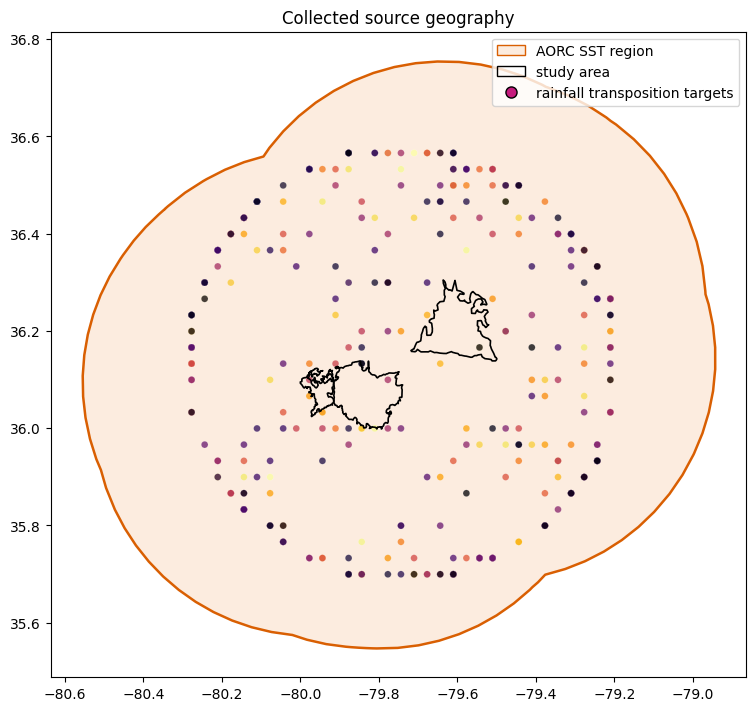

In [14]:
# Plot the SST region, study area, and rainfall transposition targets.
import geopandas as gpd

study_area = gpd.read_file(_location_path(config["grid_footprint"]["source"])).to_crs("EPSG:4326")
sst_region = gpd.read_file(
    _location_path(config["collection"]["aorc_sst"]["transposition_region"]["geometry_file"])
).to_crs("EPSG:4326")
rainfall = _read_csv(paths["aorc_sst_rainfall_members_csv"], parse_dates=["storm_start", "storm_end"])

lon_column = _first_column(rainfall, ["centroid_lon", "transposed_centroid_lon"])
lat_column = _first_column(rainfall, ["centroid_lat", "transposed_centroid_lat"])
value_column = _first_column(rainfall, ["max_precip_in", "mean_precip_in", "max", "mean"])

display(pd.Series({
    "study_area_features": len(study_area),
    "sst_region_features": len(sst_region),
    "rainfall_rows": len(rainfall),
    "longitude_column": lon_column,
    "latitude_column": lat_column,
    "value_column": value_column,
}, name="sst_plot_inputs"))

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
sst_region.plot(ax=ax, facecolor="#f4a26133", edgecolor="#d95f02", linewidth=1.8)
study_area.boundary.plot(ax=ax, color="black", linewidth=1.2)

if not rainfall.empty and lon_column and lat_column:
    rainfall_points = gpd.GeoDataFrame(
        rainfall.dropna(subset=[lon_column, lat_column]),
        geometry=gpd.points_from_xy(rainfall[lon_column], rainfall[lat_column]),
        crs="EPSG:4326",
    )
    rainfall_points.plot(
        ax=ax,
        column=value_column,
        cmap="inferno_r",
        markersize=24,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.15,
        legend=value_column is not None,
        legend_kwds={"label": "72h rainfall magnitude", "shrink": 0.62},
    )

ax.legend(
    handles=[
        Patch(facecolor="#f4a26133", edgecolor="#d95f02", label="AORC SST region"),
        Patch(facecolor="none", edgecolor="black", label="study area"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#c51b7d", markersize=8, label="rainfall transposition targets"),
    ],
    loc="best",
)
ax.set_title("Collected source geography")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()


### USGS Streamgages

Reviewed streamgages are plotted against the same source geography used during the review gate: evaluation footprint, SFINCS coverage, Wflow watershed search domain, and SST region.


,label,path,edgecolor,linestyle
0,SMART-DS evaluation footprint,data/static/aoi/evaluation_footprint.geojson,black,-
1,SFINCS coverage bbox,data/static/aoi/bbox.geojson,#dc2626,--
2,Wflow watershed search domain,data/static/aoi/wflow_nhdplus_watersheds.geojson,#059669,-.
3,AORC SST transposition region,data/sources/aorc_sst/transposition_regions/tr...,#2563eb,:


,artifact,label,path,exists,feature_count
0,candidate active gages,all active candidates,/home/grahamhults/projects/Flood-RM/locations/...,True,122
1,reviewed streamgage network,reviewed artifact,/home/grahamhults/projects/Flood-RM/locations/...,True,33
2,area layer,SMART-DS evaluation footprint,/home/grahamhults/projects/Flood-RM/locations/...,True,3
3,area layer,SFINCS coverage bbox,/home/grahamhults/projects/Flood-RM/locations/...,True,1
4,area layer,Wflow watershed search domain,/home/grahamhults/projects/Flood-RM/locations/...,True,1
5,area layer,AORC SST transposition region,/home/grahamhults/projects/Flood-RM/locations/...,True,1
6,used_reviewed_gages,active accepted gages,/home/grahamhults/projects/Flood-RM/locations/...,True,33
7,other_candidate_gages,active candidates not in reviewed network,/home/grahamhults/projects/Flood-RM/locations/...,True,89


,check,value,path
0,configured NWIS search bbox covers Wflow water...,True,/home/grahamhults/projects/Flood-RM/locations/...
1,active candidate gages inside Wflow watershed,33 of 122,/home/grahamhults/projects/Flood-RM/locations/...
2,reviewed gages inside Wflow watershed,33 of 33,/home/grahamhults/projects/Flood-RM/locations/...
3,active accepted reviewed gages inside Wflow wa...,33 of 33,/home/grahamhults/projects/Flood-RM/locations/...


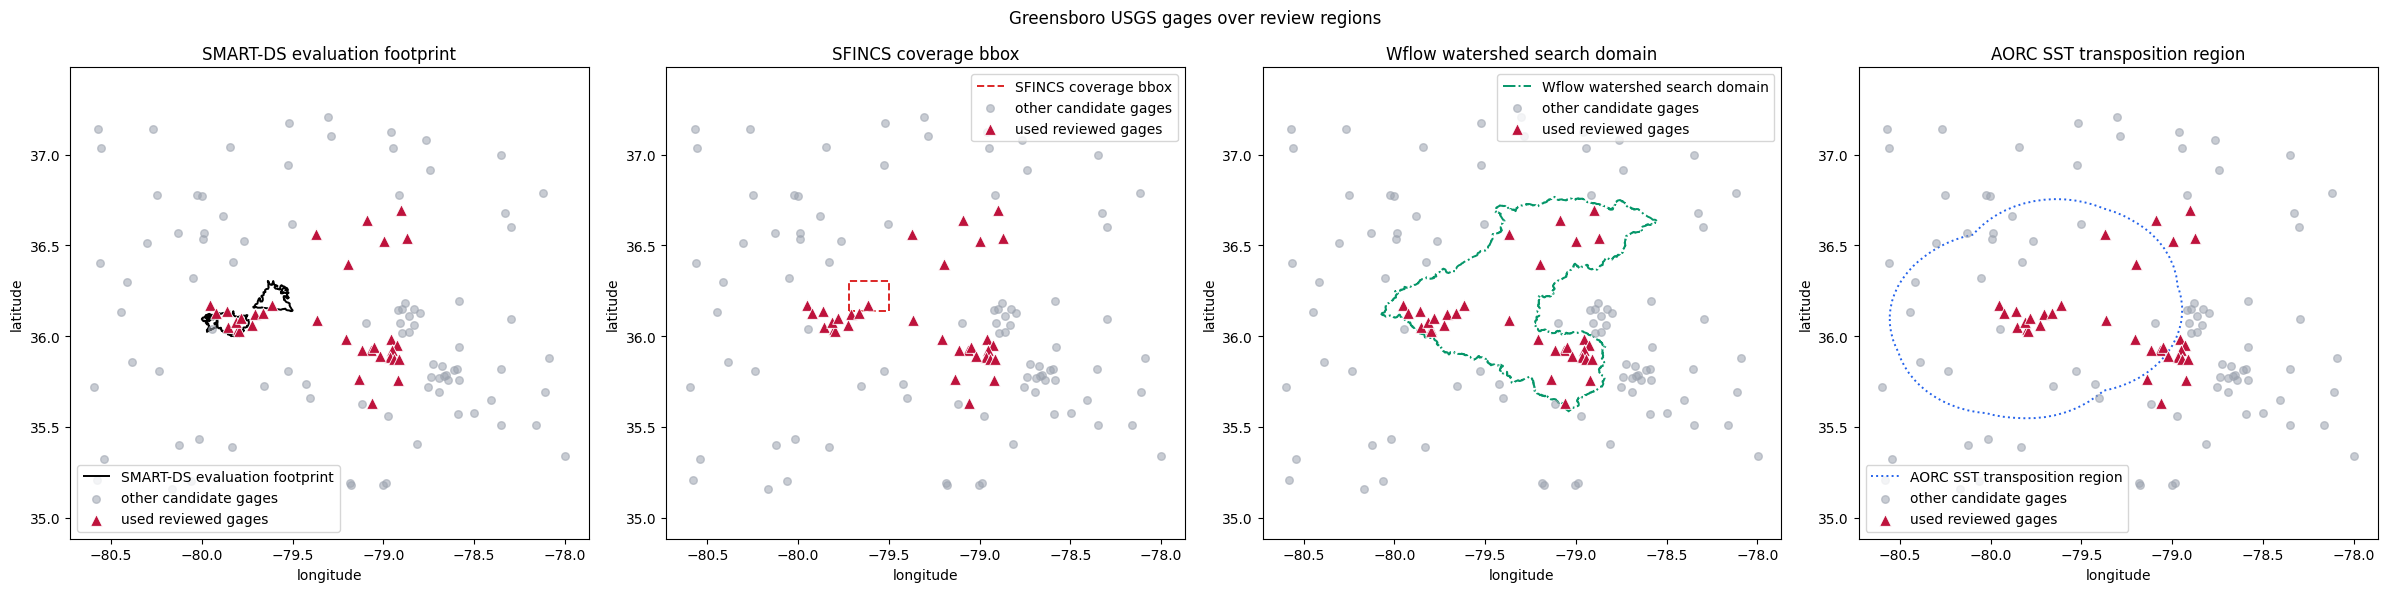

In [15]:
# Plot reviewed and candidate USGS streamgages over the source review geography.
area_layer_specs = collect.review_layers(runtime)
display(pd.DataFrame(area_layer_specs)[["label", "path", "edgecolor", "linestyle"]])

if runtime.candidate_path.exists() and runtime.reviewed_network_path.exists():
    streamgage_qa = collect.plot_review(runtime, area_layer_specs)
    display(streamgage_qa.artifact_summary)
    display(streamgage_qa.gage_domain_summary)
else:
    display(pd.Series({
        "status": "missing streamgage plot inputs",
        "candidate_gages": str(runtime.candidate_path),
        "candidate_gages_exist": runtime.candidate_path.exists(),
        "reviewed_network": str(runtime.reviewed_network_path),
        "reviewed_network_exists": runtime.reviewed_network_path.exists(),
    }, name="usgs_streamgage_plot"))


### NWM Soil Moisture

Soil moisture is summarized across configured NWM points and layers.


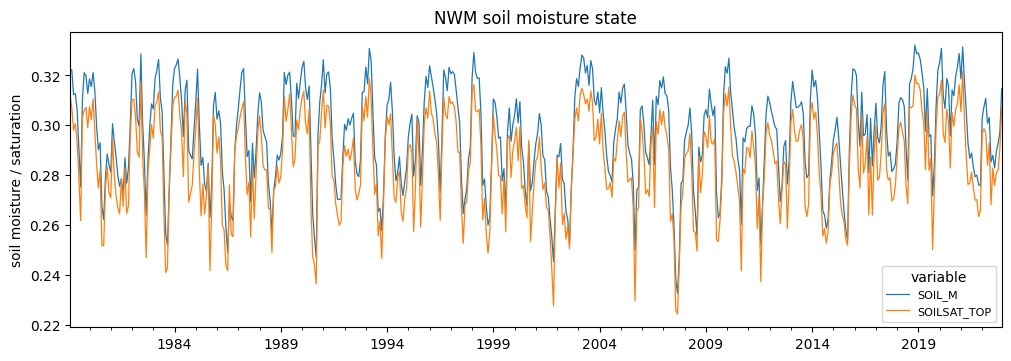

requested_variables                                [SOIL_M, SOILSAT_TOP]
available_variables                                [SOIL_M, SOILSAT_TOP]
missing_variables                                                     []
csv                    /home/grahamhults/projects/Flood-RM/locations/...
Name: nwm_soil_moisture_status, dtype: object

In [16]:
# Plot monthly mean NWM soil moisture variables when available.
soil_moisture = _read_csv(paths["nwm_soil_moisture_csv"], parse_dates=["time"])
requested_soil_variables = list(config["collection"].get("nwm", {}).get("soil_moisture", {}).get("variables", []))
available_soil_variables = [name for name in requested_soil_variables if name in soil_moisture.columns]
legacy_soil_variable = _first_column(soil_moisture, ["SOIL_M", "soil_m", "soil_moisture"])
if legacy_soil_variable and legacy_soil_variable not in available_soil_variables:
    available_soil_variables.append(legacy_soil_variable)
missing_soil_variables = [name for name in requested_soil_variables if name not in soil_moisture.columns]

if not soil_moisture.empty and available_soil_variables:
    monthly = (
        soil_moisture.groupby("time")[available_soil_variables]
        .mean()
        .resample("MS")
        .mean()
    )
    fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
    monthly.plot(ax=ax, linewidth=0.9)
    ax.set_title("NWM soil moisture state")
    ax.set_xlabel("")
    ax.set_ylabel("soil moisture / saturation")
    ax.legend(title="variable", loc="best", fontsize=8)
    plt.show()

display(pd.Series({
    "requested_variables": requested_soil_variables,
    "available_variables": available_soil_variables,
    "missing_variables": missing_soil_variables,
    "csv": str(paths["nwm_soil_moisture_csv"]),
}, name="nwm_soil_moisture_status"))


### AORC SST Rainfall

Rainfall members are shown as selected-event magnitude and distribution summaries.


rainfall_rows                                                     440
rainfall_members    /home/grahamhults/projects/Flood-RM/locations/...
Name: aorc_sst_rainfall_plot_inputs, dtype: object

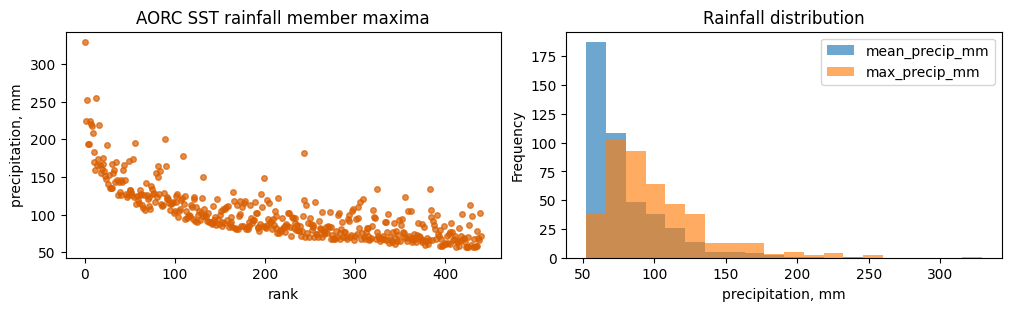

In [17]:
# Plot compact AORC SST rainfall member summaries.
rainfall = _read_csv(paths["aorc_sst_rainfall_members_csv"], parse_dates=["storm_start", "storm_end"])

display(pd.Series({
    "rainfall_rows": len(rainfall),
    "rainfall_members": str(paths["aorc_sst_rainfall_members_csv"]),
}, name="aorc_sst_rainfall_plot_inputs"))

if not rainfall.empty:
    max_column = _first_column(rainfall, ["max_precip_mm", "max_precip_in", "max"])
    mean_column = _first_column(rainfall, ["mean_precip_mm", "mean_precip_in", "mean"])
    if max_column is None or mean_column is None:
        raise KeyError("rainfall members need max and mean precipitation columns")
    unit = "mm"
    if "precip_units" in rainfall and rainfall["precip_units"].notna().any():
        unit = str(rainfall["precip_units"].dropna().iloc[0])
    elif str(max_column).endswith("_in"):
        unit = "in"
    fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
    rainfall.plot.scatter(x="rank", y=max_column, ax=axes[0], color="#d95f02", s=16, alpha=0.7)
    axes[0].set_title("AORC SST rainfall member maxima")
    axes[0].set_xlabel("rank")
    axes[0].set_ylabel(f"precipitation, {unit}")
    rainfall[[mean_column, max_column]].plot.hist(ax=axes[1], bins=20, alpha=0.65)
    axes[1].set_title("Rainfall distribution")
    axes[1].set_xlabel(f"precipitation, {unit}")
    plt.show()
